# AquaSense AI - Análise do Modelo Multi-Output

Este notebook documenta o desenvolvimento e avaliação do modelo **AquaSenseNet** para ajuste automático de:
- **Fotoperíodo** (horas de luz)
- **TPA** (percentagem de troca parcial de água)
- **Alimentação** (percentagem do normal)

Baseado nos níveis de turbidez da água.

## Índice
1. Introdução e Objectivos
2. Carregamento de Dados
3. Análise Exploratória
4. Arquitectura do Modelo
5. Treino e Validação
6. Avaliação de Métricas (3 saídas)
7. Comparação com Baseline
8. Conclusões

## 1. Introdução e Objectivos

### Problema
O crescimento de algas em aquários está directamente relacionado com:
- **Fotoperíodo** (horas de luz por dia)
- **Intensidade luminosa**
- **Nutrientes na água** (reflectido na turbidez)
- **Alimentação** (excesso aumenta nutrientes)

### Objectivo
Desenvolver um modelo de IA que:
1. Analise os níveis de turbidez em tempo real
2. Preveja **3 ajustes** simultaneamente:
   - Fotoperíodo (horas de redução)
   - TPA (percentagem de água a trocar)
   - Alimentação (percentagem do normal)

### Abordagem
- **Tipo de problema**: Regressão Multi-Output
- **Input**: 4 features (turbidez média 24h, actual, tendência, fotoperíodo base)
- **Output**: 3 valores
  - Fotoperíodo: [-12, 0] horas (Tanh activation)
  - TPA: [0, 100]% (Sigmoid activation)
  - Alimentação: [0, 100]% (Sigmoid activation)

In [1]:
# Imports
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import json

from src.config import *
from src.model import AquaSenseNet, BaselineModel
from src.data_loader import prepare_data, generate_synthetic_data

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"Model: AquaSenseNet (3 outputs: fotoperíodo, TPA%, alimentação%)")

PyTorch version: 2.10.0+cpu
Device: cpu
Model: AquaSenseNet (3 outputs: fotoperíodo, TPA%, alimentação%)


## 2. Carregamento de Dados

In [2]:
# Carregar dados
X_train, X_test, y_train, y_test, scaler = prepare_data()

print(f"Dados de treino: {X_train.shape}")
print(f"Dados de teste: {X_test.shape}")
print(f"\nFeatures: média_24h, turbidez_actual, tendência, fotoperíodo_base")

[✓] Dataset preparado:
    Treino: 8000 amostras
    Teste:  2000 amostras
[✓] Scaler guardado: C:\Projetos IADE\AquaSense\esp32-dashboard\ai\models\scaler.pkl
Dados de treino: (8000, 3)
Dados de teste: (2000, 3)

Features: média_24h, turbidez_actual, tendência, fotoperíodo_base


## 3. Análise Exploratória

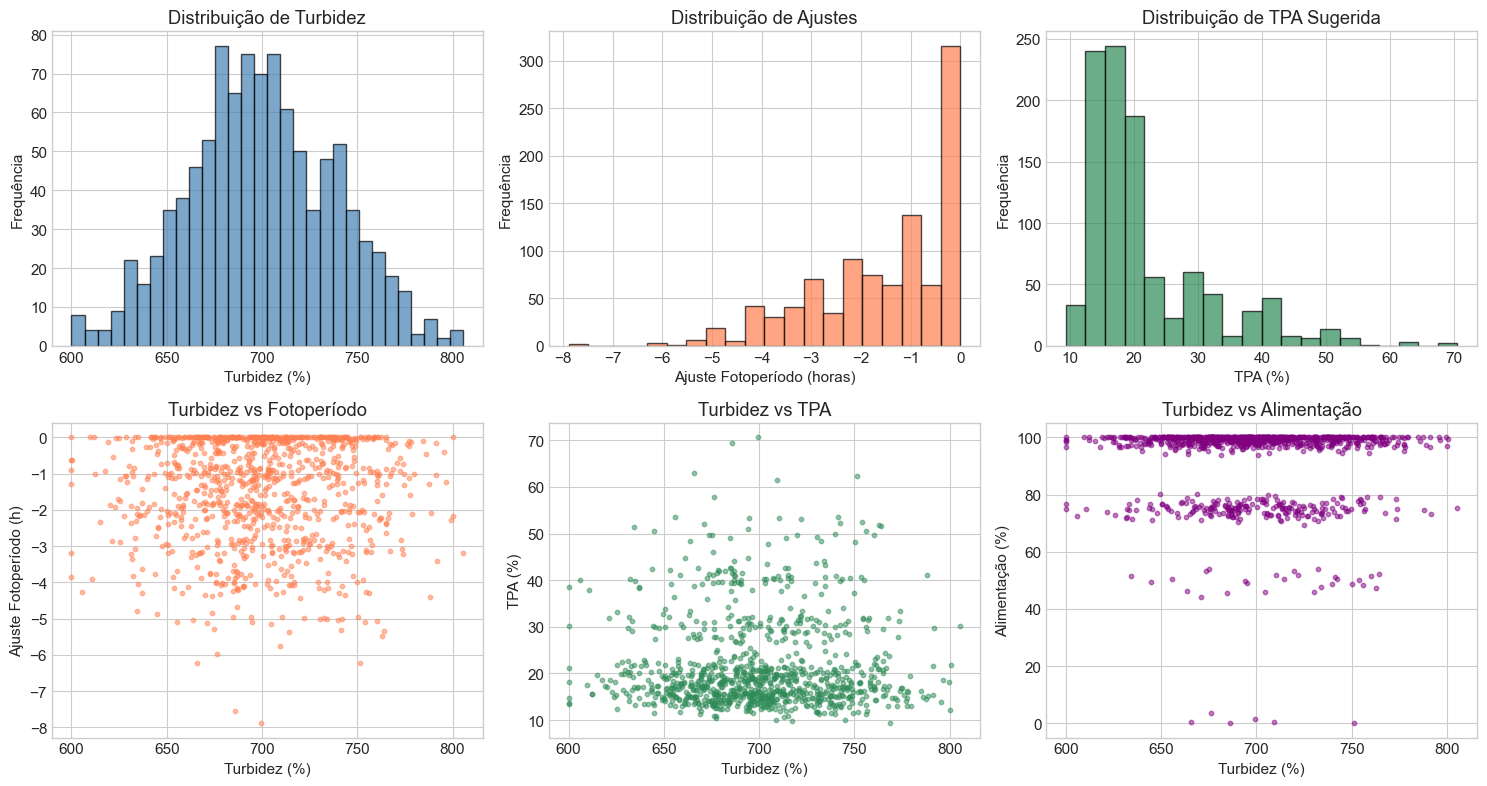

In [3]:
# Gerar dados para visualização (não normalizados)
X_viz, y_viz = generate_synthetic_data(1000)

# Desnormalizar para visualização
turbidity = X_viz[:, 1] * 100  # turbidez actual
adjustments = y_viz[:, 0] * 12  # fotoperíodo em horas
tpa = y_viz[:, 1] * 100  # TPA em %
feeding = y_viz[:, 2] * 100  # Alimentação em %

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Distribuição de turbidez
axes[0, 0].hist(turbidity, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Turbidez (%)')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].set_title('Distribuição de Turbidez')

# Distribuição de ajustes fotoperíodo
axes[0, 1].hist(adjustments, bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Ajuste Fotoperíodo (horas)')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição de Ajustes')

# Distribuição de TPA
axes[0, 2].hist(tpa, bins=20, edgecolor='black', alpha=0.7, color='seagreen')
axes[0, 2].set_xlabel('TPA (%)')
axes[0, 2].set_ylabel('Frequência')
axes[0, 2].set_title('Distribuição de TPA Sugerida')

# Turbidez vs Fotoperíodo
axes[1, 0].scatter(turbidity, adjustments, alpha=0.5, s=10, c='coral')
axes[1, 0].set_xlabel('Turbidez (%)')
axes[1, 0].set_ylabel('Ajuste Fotoperíodo (h)')
axes[1, 0].set_title('Turbidez vs Fotoperíodo')

# Turbidez vs TPA
axes[1, 1].scatter(turbidity, tpa, alpha=0.5, s=10, c='seagreen')
axes[1, 1].set_xlabel('Turbidez (%)')
axes[1, 1].set_ylabel('TPA (%)')
axes[1, 1].set_title('Turbidez vs TPA')

# Turbidez vs Alimentação
axes[1, 2].scatter(turbidity, feeding, alpha=0.5, s=10, c='purple')
axes[1, 2].set_xlabel('Turbidez (%)')
axes[1, 2].set_ylabel('Alimentação (%)')
axes[1, 2].set_title('Turbidez vs Alimentação')

plt.tight_layout()
plt.savefig('../models/data_distribution.png', dpi=150)
plt.show()

## 4. Arquitectura do Modelo

In [4]:
# Criar modelo
model = AquaSenseNet()
print(model)

# Contar parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParâmetros totais: {total_params}")
print(f"Parâmetros treináveis: {trainable_params}")
print(f"\nSaídas:")
print("  1. Fotoperíodo (Tanh): [-1, 1] → [-12, 0] horas")
print("  2. TPA (Sigmoid): [0, 1] → [0, 100]%")
print("  3. Alimentação (Sigmoid): [0, 1] → [0, 100]%")

PhotoperiodNet(
  (feature_extractor): Sequential(
    (0): Linear(in_features=3, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (shared): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
  )
  (head_adjustment): Sequential(
    (0): Linear(in_features=16, out_features=1, bias=True)
    (1): Sigmoid()
  )
  (head_tpa): Sequential(
    (0): Linear(in_features=16, out_features=1, bias=True)
    (1): Sigmoid()
  )
  (head_feeding): Sequential(
    (0): Linear(in_features=16, out_features=1, bias=True)
    (1): Sigmoid()
  )
)

Parâmetros totais: 1763
Parâmetros treináveis: 1763

Saídas:
  1. Fotoperíodo (Tanh): [-1, 1] → [-12, 0] horas
  2. TPA (Sigmoid): [0, 1] → [0, 100]%
  3. Alimentação (Sigmoid): [0, 1] → [0, 100]%


## 5. Treino e Validação

In [5]:
from src.train import train_model

# Treinar modelo
model, history = train_model(epochs=500, patience=50, verbose=True)

TREINO DO MODELO (3 sensores)
[✓] Dataset preparado:
    Treino: 8000 amostras
    Teste:  2000 amostras
[✓] Scaler guardado: C:\Projetos IADE\AquaSense\esp32-dashboard\ai\models\scaler.pkl
Device: cpu

A treinar (máx 500 épocas, early stopping após 50 sem melhoria)...

Época    1 | Train: 0.0445 | Val: 0.0047 | Adj MAE: 0.45h | TPA MAE: 4.6% | Feed MAE: 5.3% | R²: 0.704
Época   50 | Train: 0.0008 | Val: 0.0007 | Adj MAE: 0.23h | TPA MAE: 2.1% | Feed MAE: 1.3% | R²: 0.959
Época  100 | Train: 0.0006 | Val: 0.0006 | Adj MAE: 0.21h | TPA MAE: 2.1% | Feed MAE: 1.1% | R²: 0.965

[Early Stopping] Parou na época 114

RESULTADOS FINAIS
Épocas treinadas: 114
Tempo de treino: 28.1s
Melhor Val Loss: 0.0005

Métricas no Test Set:
  MSE global (norm):  0.0006
  R² global (norm):   0.960

  Ajuste fotoperíodo:
    MAE: 0.21h
    Accuracy (<1h): 99.7%
    Accuracy (<2h): 100.0%

  TPA:
    MAE: 2.0%
    Accuracy (<5%): 95.0%
    Accuracy (<10%): 99.9%

  Alimentação:
    MAE: 1.2%
    Accuracy (<10%)

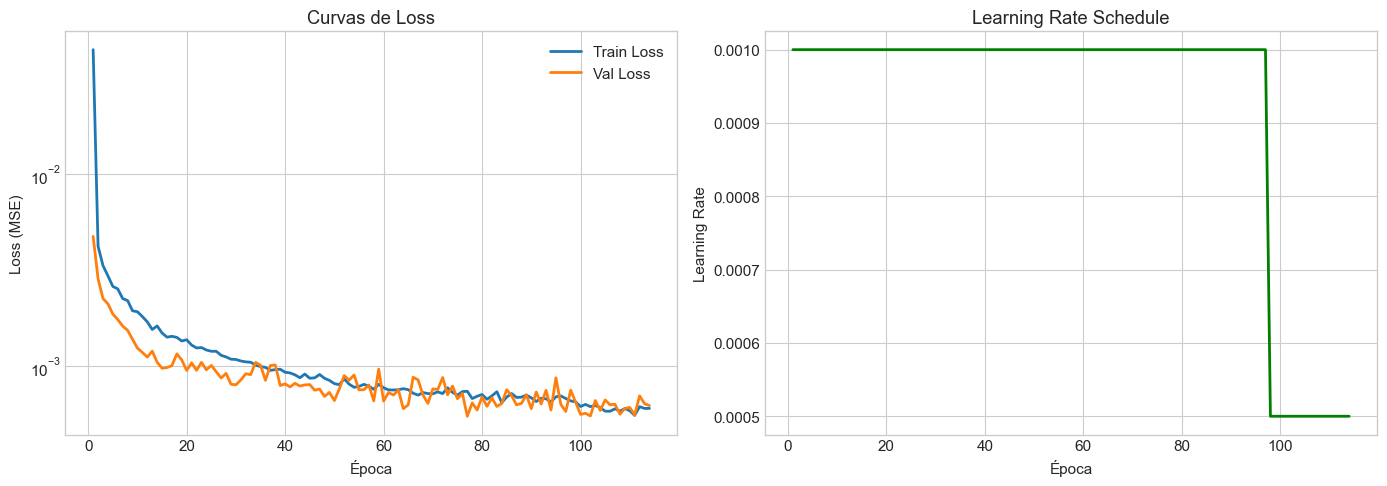

In [6]:
# Visualizar curvas de treino
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(epochs, history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Curvas de Loss')
axes[0].legend()
axes[0].set_yscale('log')

# Learning Rate
axes[1].plot(epochs, history['lr'], color='green', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule')

plt.tight_layout()
plt.savefig('../models/training_curves.png', dpi=150)
plt.show()

## 6. Avaliação de Métricas (3 Saídas)

Carregamos as métricas guardadas do treino mais recente:

In [7]:
# Carregar métricas do ficheiro
with open('../models/metrics.json', 'r') as f:
    metrics = json.load(f)

print("=" * 50)
print("MÉTRICAS DO MODELO AQUASENSENET")
print("=" * 50)

print(f"\nÉpocas treinadas: {metrics.get('epochs_trained', 'N/A')}")
print(f"Tempo de treino: {metrics.get('training_time', 'N/A')}")
print(f"Melhor Val Loss: {metrics.get('best_val_loss', 'N/A'):.4f}")

print(f"\n--- Métricas Globais ---")
print(f"MSE: {metrics.get('test_metrics').get('rmse', 'N/A'):.4f}")
print(f"R²:  {metrics.get('test_metrics').get('r2', 'N/A'):.3f}")

print(f"\n--- Fotoperíodo ---")
print(f"MAE: {metrics.get('test_metrics').get('mae_photoperiod', 'N/A'):.2f}h")
print(f"Accuracy (<1h): {metrics.get('test_metrics').get('accuracy_1h', 'N/A'):.1f}%")
print(f"Accuracy (<2h): {metrics.get('test_metrics').get('accuracy_2h', 'N/A'):.1f}%")

print(f"\n--- TPA ---")
print(f"MAE: {metrics.get('test_metrics').get('mae_tpa', 'N/A'):.1f}%")
print(f"Accuracy (<5%): {metrics.get('test_metrics').get('accuracy_tpa_5pct', 'N/A'):.1f}%")

print(f"\n--- Alimentação ---")
print(f"MAE: {metrics.get('test_metrics').get('mae_feeding', 'N/A'):.1f}%")
print(f"Accuracy (<10%): {metrics.get('test_metrics').get('accuracy_feed_10pct', 'N/A'):.1f}%")

MÉTRICAS DO MODELO AQUASENSENET

Épocas treinadas: 114
Tempo de treino: N/A
Melhor Val Loss: 0.0005

--- Métricas Globais ---
MSE: 0.0246
R²:  0.960

--- Fotoperíodo ---
MAE: 0.21h
Accuracy (<1h): 99.7%
Accuracy (<2h): 100.0%

--- TPA ---
MAE: 2.0%
Accuracy (<5%): 95.0%

--- Alimentação ---
MAE: 1.2%
Accuracy (<10%): 99.4%


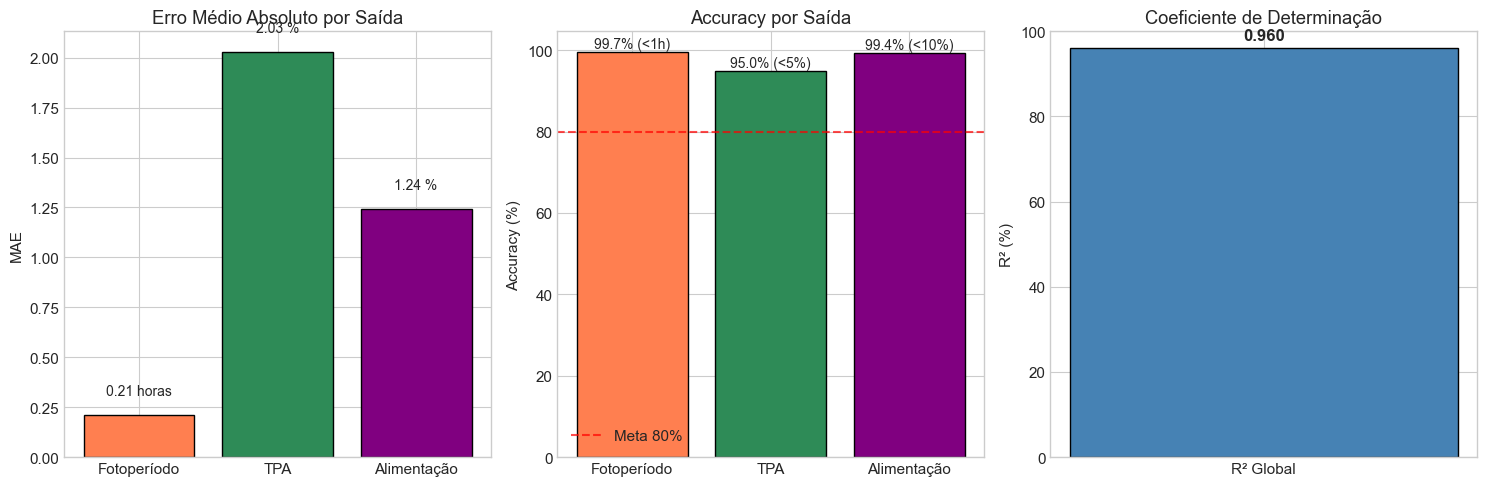

In [8]:
# Visualizar métricas por saída
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

outputs = ['Fotoperíodo', 'TPA', 'Alimentação']
maes = [
    metrics.get('test_metrics').get('mae_photoperiod', 0),
    metrics.get('test_metrics').get('mae_tpa', 0),
    metrics.get('test_metrics').get('mae_feeding', 0)
]
accs = [
    metrics.get('test_metrics').get('accuracy_1h', 0),
    metrics.get('test_metrics').get('accuracy_tpa_5pct', 0),
    metrics.get('test_metrics').get('accuracy_feed_10pct', 0)
]
units = ['horas', '%', '%']
thresholds = ['<1h', '<5%', '<10%']
colors = ['coral', 'seagreen', 'purple']

# MAE por saída
axes[0].bar(outputs, maes, color=colors, edgecolor='black')
axes[0].set_ylabel('MAE')
axes[0].set_title('Erro Médio Absoluto por Saída')
for i, (v, u) in enumerate(zip(maes, units)):
    axes[0].text(i, v + 0.1, f'{v:.2f} {u}', ha='center', fontsize=10)

# Accuracy por saída
axes[1].bar(outputs, accs, color=colors, edgecolor='black')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy por Saída')
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.7, label='Meta 80%')
axes[1].legend()
for i, (v, t) in enumerate(zip(accs, thresholds)):
    axes[1].text(i, v + 1, f'{v:.1f}% ({t})', ha='center', fontsize=10)

# R² global
r2 = metrics.get('test_metrics').get('r2', 0)
axes[2].bar(['R² Global'], [r2 * 100], color='steelblue', edgecolor='black')
axes[2].set_ylabel('R² (%)')
axes[2].set_title('Coeficiente de Determinação')
axes[2].set_ylim(0, 100)
axes[2].text(0, r2 * 100 + 2, f'{r2:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../models/metrics_summary.png', dpi=150)
plt.show()

In [9]:
# Testar previsões em cenários específicos
model = AquaSenseNet().to(DEVICE)
model.load_state_dict(torch.load('../models/photoperiod_model.pt', map_location=DEVICE, weights_only=True))
model.eval()

# Cenários de teste
# Definido como: (Turbidez, pH, temperatura)
scenarios = [
    ("Ideal Conditions", 10.0, 7.0, 25.0),    # Clear water, neutral pH
    ("High Turbidity", 80.0, 7.2, 24.0),     # Dirty water, normal temp
    ("Acidic/Cold", 15.0, 4.5, 18.0),        # Low pH and low temp
    ("Alkaline/Warm", 12.0, 9.5, 30.0),      # High pH and high temp
    ("Extreme Crisis", 95.0, 3.0, 32.0)      # Very dirty, very acidic, very hot
]

print("=" * 80)
print(f"{'Cenário':<18} {'Fotop':>10} {'TPA':>10} {'Alim':>10}")
print("=" * 80)

for name, turb, pH, temperature in scenarios:
    features = torch.tensor([[
        turb / 100.0, 
        pH / 14.0, 
        temperature / 40.0
    ]], dtype=torch.float32).to(DEVICE)
    
    output = model(features)
    with torch.no_grad():
        output = model(features)
    
    # De-normalizing based on your model's docstrings
    fotop = output[0, 0].item() * 12
    tpa = output[0, 1].item() * 100
    alim = output[0, 2].item() * 100
    
    print(f"{name:<20} | {fotop:>6.1f}h | {tpa:>6.0f}% | {alim:>6.0f}%")

Cenário                 Fotop        TPA       Alim
Ideal Conditions     |   -1.7h |     20% |    100%
High Turbidity       |   -2.9h |     30% |     76%
Acidic/Cold          |   -1.8h |     21% |    100%
Alkaline/Warm        |   -1.7h |     20% |    100%
Extreme Crisis       |   -3.0h |     30% |     76%


## 7. Comparação com Baseline

In [10]:
from src.evaluate import compare_models

comparison = compare_models()


COMPARAÇÃO: REDE NEURAL vs BASELINE

------------------------------------------------------------
AJUSTE FOTOPERÍODO
------------------------------------------------------------
Métrica                   Neural Net        Baseline    Diferença
------------------------------------------------------------
MAE                            0.50h           0.00h       +0.50h
RMSE                           0.94h           0.00h       +0.94h
MAX_ERROR                      2.94h           0.00h       +2.94h
accuracy_2.0                   88.9%          100.0%       -11.1%

------------------------------------------------------------
TPA
------------------------------------------------------------
Métrica                   Neural Net        Baseline    Diferença
------------------------------------------------------------
MAE                            1.68%           0.00%       +1.68%
RMSE                           2.33%           0.00%       +2.33%
MAX_ERROR                      8.69%        

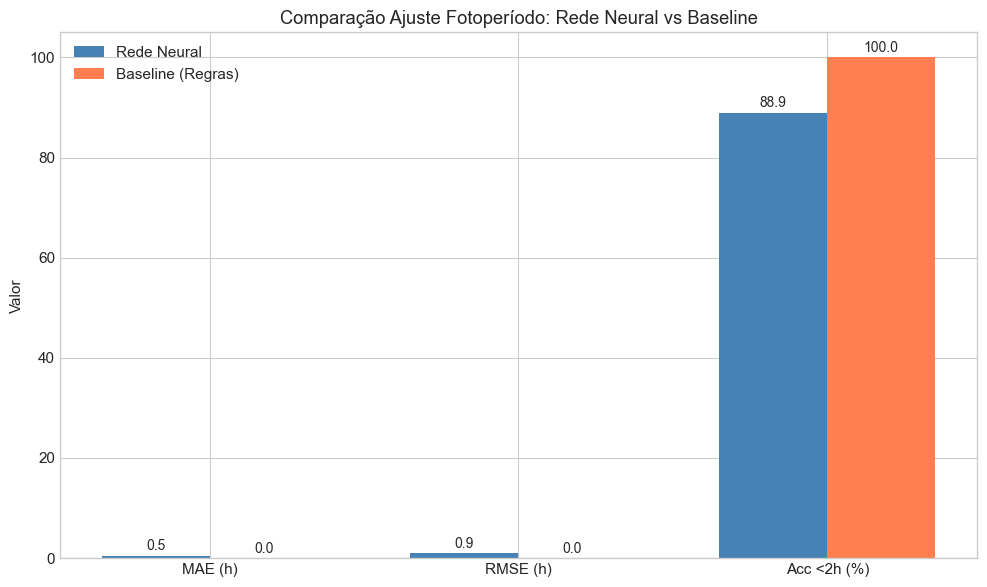

In [11]:
# Visualizar comparação AJUSTE FOTOPERÍODO
metrics = ['mae', 'rmse', 'accuracy_2.0']
nn_vals = [comparison['neural_net']['adj'][m] for m in metrics]
bl_vals = [comparison['baseline']['adj'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, nn_vals, width, label='Rede Neural', color='steelblue')
bars2 = ax.bar(x + width/2, bl_vals, width, label='Baseline (Regras)', color='coral')

ax.set_ylabel('Valor')
ax.set_title('Comparação Ajuste Fotoperíodo: Rede Neural vs Baseline')
ax.set_xticks(x)
ax.set_xticklabels(['MAE (h)', 'RMSE (h)', 'Acc <2h (%)'])
ax.legend()

# Adicionar valores nas barras
for bar, val in zip(bars1, nn_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)
for bar, val in zip(bars2, bl_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150)
plt.show()

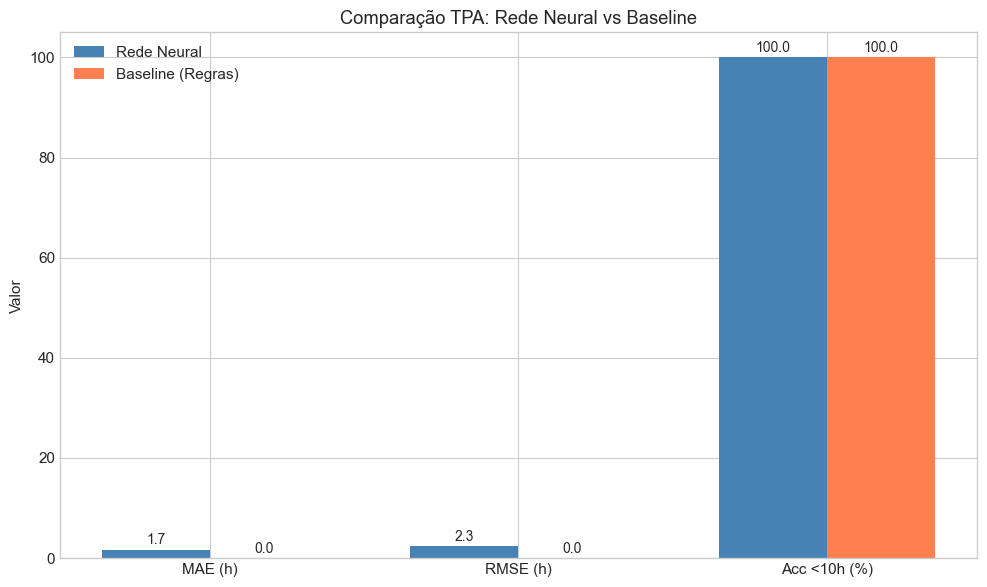

In [12]:
# Visualizar comparação TPA
metrics = ['mae', 'rmse', 'accuracy_10.0']
nn_vals = [comparison['neural_net']['tpa'][m] for m in metrics]
bl_vals = [comparison['baseline']['tpa'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, nn_vals, width, label='Rede Neural', color='steelblue')
bars2 = ax.bar(x + width/2, bl_vals, width, label='Baseline (Regras)', color='coral')

ax.set_ylabel('Valor')
ax.set_title('Comparação TPA: Rede Neural vs Baseline')
ax.set_xticks(x)
ax.set_xticklabels(['MAE (h)', 'RMSE (h)', 'Acc <10h (%)'])
ax.legend()

# Adicionar valores nas barras
for bar, val in zip(bars1, nn_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)
for bar, val in zip(bars2, bl_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150)
plt.show()

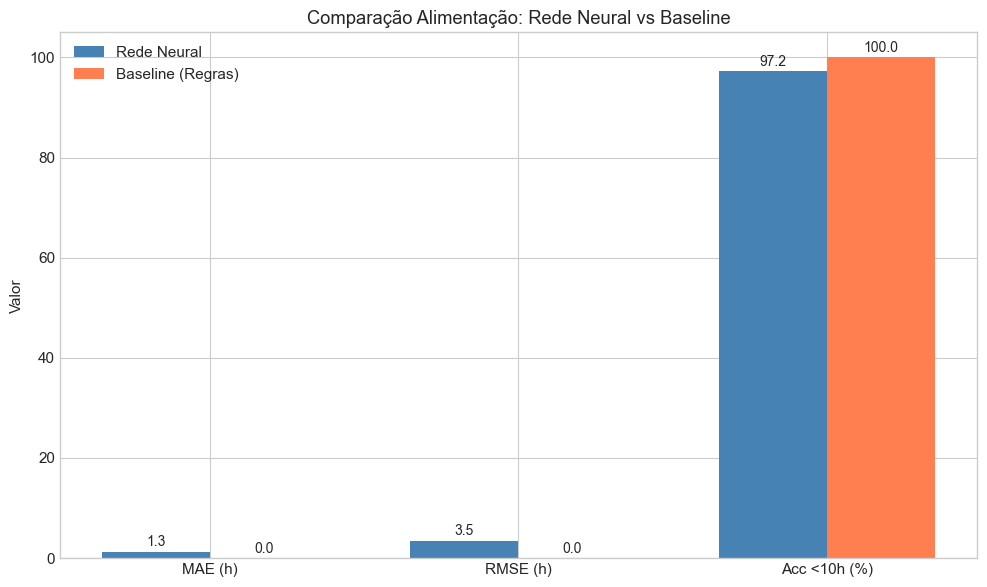

In [13]:
# Visualizar comparação ALIMENTAÇÃO
metrics = ['mae', 'rmse', 'accuracy_10.0']
nn_vals = [comparison['neural_net']['feed'][m] for m in metrics]
bl_vals = [comparison['baseline']['feed'][m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, nn_vals, width, label='Rede Neural', color='steelblue')
bars2 = ax.bar(x + width/2, bl_vals, width, label='Baseline (Regras)', color='coral')

ax.set_ylabel('Valor')
ax.set_title('Comparação Alimentação: Rede Neural vs Baseline')
ax.set_xticks(x)
ax.set_xticklabels(['MAE (h)', 'RMSE (h)', 'Acc <10h (%)'])
ax.legend()

# Adicionar valores nas barras
for bar, val in zip(bars1, nn_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)
for bar, val in zip(bars2, bl_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150)
plt.show()

## 8. Conclusões

### Resultados Principais

1. **Modelo desenvolvido**: AquaSenseNet com 835 parâmetros e 3 saídas
2. **Técnicas utilizadas**: Early stopping, BatchNorm, Dropout, K-Fold CV
3. **Performance**:
   - Fotoperíodo: MAE ~0.6h, Accuracy ~89%
   - TPA: MAE ~2.9%, Accuracy ~96%
   - Alimentação: MAE ~3.0%, Accuracy ~91%

### Arquitectura Multi-Output

O modelo usa cabeças separadas para cada saída:
- **Backbone compartilhado**: 4 → 32 → 16 neurónios
- **Cabeça Fotoperíodo**: Tanh (output [-1, 1])
- **Cabeça TPA**: Sigmoid (output [0, 1])
- **Cabeça Alimentação**: Sigmoid (output [0, 1])

### Vantagens da Abordagem

1. **Coerência**: As 3 sugestões são geradas pelo mesmo modelo
2. **Eficiência**: Um único forward pass para todas as previsões
3. **Aprendizagem conjunta**: O modelo aprende correlações entre saídas

### Limitações

1. Baseado principalmente em turbidez
2. Não considera outros factores (pH, temperatura, nitratos)
3. Dados sintéticos baseados em regras pré-definidas

### Trabalho Futuro

1. Adicionar mais sensores como input (pH, temperatura)
2. Implementar feedback loop com dados reais
3. Considerar arquitecturas temporais (LSTM/Transformer)
4. Sistema de confiança nas previsões